# Imports

In [1]:
import sys, os

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if ROOT not in sys.path:
    sys.path.append(ROOT)

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from modules.attachment_extractor import extract_attachment_text
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data + filter attachments

In [3]:
df = pd.read_csv("../../datasets/processed/final_combined.csv")

# Keep only attachments with at least 20 characters (remove noise)
attach_df = df[df["attachment_text"].astype(str).str.strip().str.len() > 4].copy()
print("Total usable attachment samples:", len(attach_df))

train_df, val_df = train_test_split(
    attach_df,
    test_size=0.1,
    random_state=42,
    stratify=attach_df["label"]
)

print("Train:", len(train_df), "Val:", len(val_df))
train_df.head(5)

Total usable attachment samples: 840
Train: 756 Val: 84


/tmp/ipykernel_128331/2812143152.py:1: DtypeWarning: Columns (3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../datasets/processed/final_combined.csv")


,id,subject,body_text,attachment_text,headers_raw,from_email,to_email,reply_to_email,date,urls,header_from_reply_mismatch,header_domain_mismatch,header_suspicious_tld,header_received_count,header_to_anomaly,header_x_mailer_anomaly,header_date_malformed,label,source
159979,b244286f-c67a-4ca0-a171-13a4fecc1805,XSS Test Mail,a,<script>alert(1)</script>,From: smaloney@worldwrapps.com\nTo: bcherry@se...,smaloney@worldwrapps.com,bcherry@sempra.com,NaN,NaN,NaN,0,0,0,0,0,1,1,1,epvme_phish
147652,5cfda002-2448-4aa6-a4d0-607fbd0aa217,XSS Test Mail,huhu,"%E4%B9%80 <img src=""http://dm3/in/test.png"" x=...","From: ""Will Coleda via RT"" <parrotbug-followup...",parrotbug-followup@parrotcode.org,donna.scott@enron.com,NaN,NaN,http://dm3/in/test.png,0,0,0,0,0,1,1,1,epvme_phish
99067,49177314-a765-4f83-9245-0e9a7ea6938c,XSS Test Mail,dm3in,"%E4%B9%80 <img src=""http://dm3/in/test.png"" x=...",From: savings_from@opt30.edirectnetwork.net\nT...,savings_from@opt30.edirectnetwork.net,luiz.maurer@enron.com,NaN,NaN,http://dm3/in/test.png,0,0,0,0,0,1,1,1,epvme_phish
88449,6b28136f-5cff-457e-a5da-3aedff904a5a,XSS Test Mail,testtest,PNG  ��� IHDR���������RW���sRGB� ���gAMA�...,From: losi@pbworld.com\nTo: alfred.gilman@emai...,losi@pbworld.com,alfred.gilman@email.swmed.edu,NaN,NaN,NaN,0,0,0,0,0,1,1,1,epvme_phish
98379,718d6913-6a1b-440a-9484-5a5474463b75,XSS Test Mail,"<a href=""javasc&NewLine;ript&colon;al&NewLine;...",<html> <head></head> <body> <something:script ...,From: jlove@lockeliddell.com\nTo: sara.shackle...,jlove@lockeliddell.com,sara.shackleton@enron.com,NaN,NaN,http://www.w3.org/1999/xhtml,0,0,0,0,0,1,1,1,epvme_phish


# Load XLM-RoBERTa-Large + tokenizer

In [3]:
model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# Ensure PAD token exists
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Assigned pad_token =", tokenizer.pad_token)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
)

# VRAM optimization
model.config.pad_token_id = tokenizer.pad_token_id
model.gradient_checkpointing_enable()
model.to(device)

DEVICE: cuda


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=1024, ou

# Convert to HuggingFace Datasets + tokenize

In [4]:
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)

def tokenize(batch):
    return tokenizer(
        batch["attachment_text"],
        truncation=True,
        max_length=512,
    )

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["attachment_text"])
val_ds   = val_ds.map(tokenize, batched=True, remove_columns=["attachment_text"])

# rename label → labels for Trainer
train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format("torch",   columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 84/84 [00:00<00:00, 3319.97 examples/s]


# Data collator

In [5]:
data_collator = DataCollatorWithPadding(tokenizer)

# Metrics with sklearn

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )

    print("\nConfusion Matrix:")
    print(confusion_matrix(labels, preds))

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="attachment_model_xlmr_large_out",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=8e-6,         # LOWER LR
    lr_scheduler_type="linear",
    warmup_ratio=0.04,

    per_device_train_batch_size=2,   # SMALLER BATCH
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=1,   # NO ACCUMULATION

    num_train_epochs=5,              # MORE EPOCHS
    weight_decay=0.01,

    fp16=False,
    bf16=True,

    max_grad_norm=1.0,

    gradient_checkpointing=True,

    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    optim="adamw_torch",
    label_smoothing_factor=0.05,      # REDUCED LS
    report_to="none",
)

# Trainer + Train

In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipykernel_125252/1450023550.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.117900,0.163832,0.988095,0.988095,1.000000,0.994012
2,0.184400,0.158614,0.988095,0.988095,1.000000,0.994012
3,0.117500,0.150712,0.988095,0.988095,1.000000,0.994012
4,0.139400,0.147502,0.988095,0.988095,1.000000,0.994012
5,0.144600,0.142482,0.988095,0.988095,1.000000,0.994012



Confusion Matrix:
[[ 0  1]
 [ 0 83]]

Confusion Matrix:
[[ 0  1]
 [ 0 83]]

Confusion Matrix:
[[ 0  1]
 [ 0 83]]

Confusion Matrix:
[[ 0  1]
 [ 0 83]]

Confusion Matrix:
[[ 0  1]
 [ 0 83]]


TrainOutput(global_step=1890, training_loss=0.15204152959995168, metrics={'train_runtime': 752.1942, 'train_samples_per_second': 5.025, 'train_steps_per_second': 2.513, 'total_flos': 1652234219329008.0, 'train_loss': 0.15204152959995168, 'epoch': 5.0})

# Save Model + Tokenizer

In [9]:
# trainer.save_model("attachment_encoder_xlmr_large")
# tokenizer.save_pretrained("attachment_encoder_xlmr_large_tokenizer")

# print("Training complete and model saved.")

# Confusion Matrix Plot


Confusion Matrix:
[[ 0  1]
 [ 0 83]]


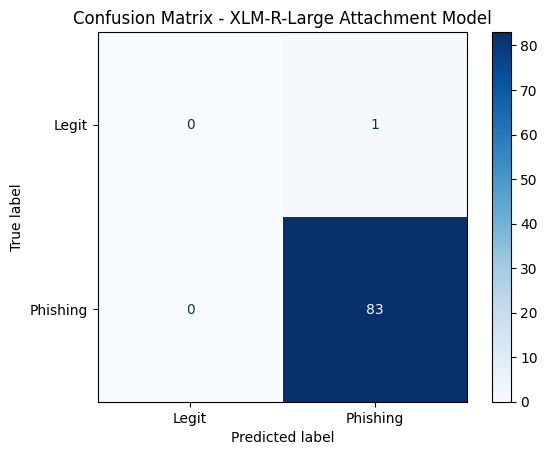

In [9]:
predictions = trainer.predict(val_ds)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - XLM-R-Large Attachment Model")
plt.show()

# Plot Loss Curve

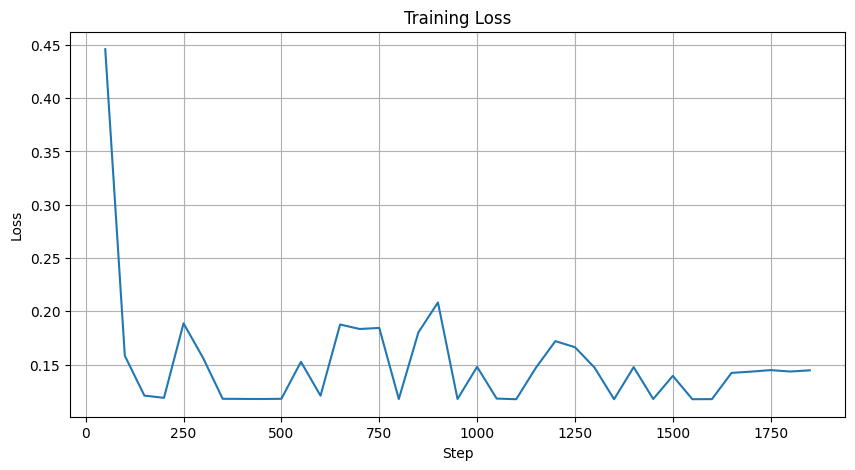

In [10]:
logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

plt.figure(figsize=(10,5))
loss_df = df_logs[df_logs["loss"].notna()]
plt.plot(loss_df["step"], loss_df["loss"])
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Plot Metrics Curve

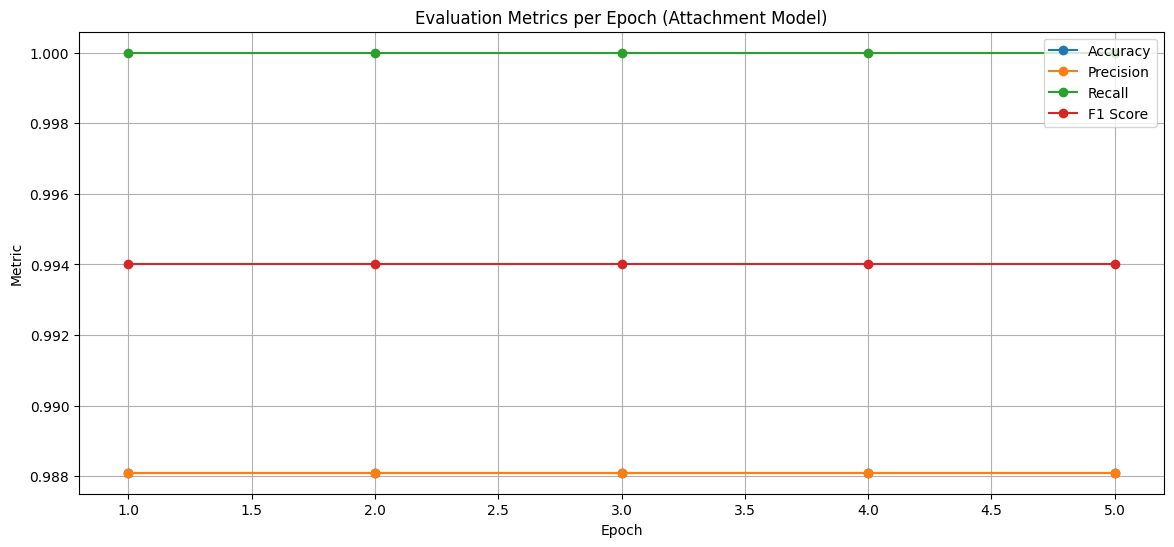

In [11]:
eval_df = df_logs[df_logs["eval_loss"].notna()].copy()

if "epoch" not in eval_df.columns:
    eval_df["epoch"] = range(1, len(eval_df)+1)

plt.figure(figsize=(14,6))

for col, label in [
    ("eval_accuracy", "Accuracy"),
    ("eval_precision", "Precision"),
    ("eval_recall", "Recall"),
    ("eval_f1", "F1 Score")
]:
    if col in eval_df:
        plt.plot(eval_df["epoch"], eval_df[col], marker="o", label=label)

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Evaluation Metrics per Epoch (Attachment Model)")
plt.legend()
plt.grid(True)
plt.show()

# Final Precision-Recall Curve

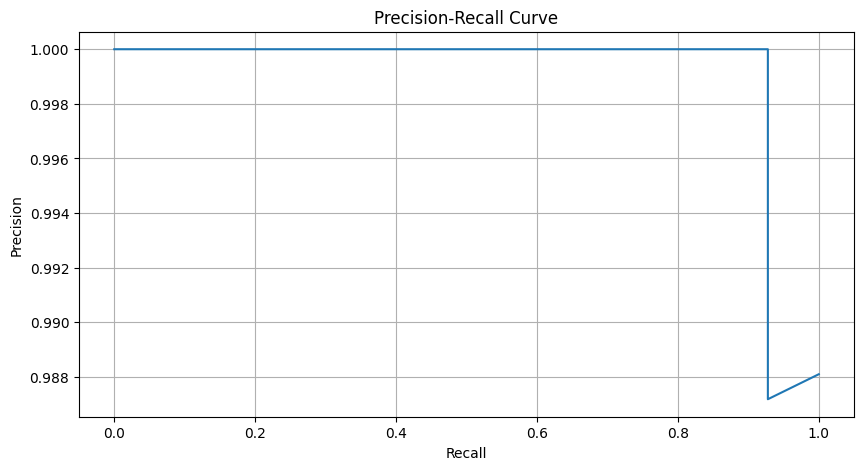

In [12]:
probs = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()
prec, rec, thresh = precision_recall_curve(y_true, probs)

plt.figure(figsize=(10,5))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# Final Classification Report

In [14]:
final_preds = predictions.predictions.argmax(-1)
print(classification_report(y_true, final_preds, target_names=["Legit", "Phishing"]))

              precision    recall  f1-score   support

       Legit       0.00      0.00      0.00         1
    Phishing       0.99      1.00      0.99        83

    accuracy                           0.99        84
   macro avg       0.49      0.50      0.50        84
weighted avg       0.98      0.99      0.98        84



/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

# Inference Helper (User Input)

In [34]:
def predict_attachment(text):
    model.eval()
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=512,
        padding="max_length",
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(-1).item()

    return {
        "prediction": "PHISHING" if pred==1 else "LEGIT",
        "prob_legit": float(probs[0][0]),
        "prob_phishing": float(probs[0][1])
    }

def predict_attachment_file(file_path):
    text = extract_attachment_text(file_path)
    if not text.strip():
        return {"error": "No extractable text from attachment."}

    return predict_attachment(text)  # reuse Stage-2B inference method

# Example:
for key, value in predict_attachment_file("1.txt").items():
    print(f"{key}: {value}")


prediction: PHISHING
prob_legit: 0.014842418022453785
prob_phishing: 0.9851576089859009
